In [40]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score


In [4]:
df = pd.read_csv('Ram_crisis.csv')
df["timestamp"] = pd.to_datetime(df["timestamp"])

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Timestamp range: {df['timestamp'].min().date()}  →  {df['timestamp'].max().date()}")
print(f"Null values    : {df.isnull().sum().sum()}")
print(f"\nColumns:\n{df.dtypes.to_string()}")
print(f"\nNumerical summary:\n{df.describe().round(2).to_string()}")

DATASET OVERVIEW
Shape          : 10,000 rows × 28 columns
Timestamp range: 2024-01-01  →  2027-01-01
Null values    : 0

Columns:
kit_id                            object
brand                             object
model_name                        object
timestamp                 datetime64[ns]
region                            object
generation                        object
form_factor                       object
capacity_gb                        int64
module_count                       int64
is_ecc                              bool
speed_mts                          int64
cas_latency                        int64
voltage                          float64
timing_string                     object
die_manufacturer                  object
die_type                          object
true_latency_ns                  float64
bandwidth_per_dollar             float64
latency_value_index              float64
speed_premium_ratio              float64
price_per_gb                     float64
price_us

In [5]:
df["year"]  = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month
df["quarter"] = df["timestamp"].dt.quarter

In [6]:
df_clean = df[df["price_status"] != "Listing-Error"].copy()
print(f"\nRows after removing Listing-Errors: {len(df_clean):,}")


Rows after removing Listing-Errors: 9,792


In [7]:
encoders = {}
for col in ["generation", "market_segment", "region", "price_status",
            "die_manufacturer", "die_type", "form_factor"]:
    le = LabelEncoder()
    df_clean[f"{col}_enc"] = le.fit_transform(df_clean[col])
    encoders[col] = le


In [8]:
df_clean["is_shortage"] = (df_clean["price_status"] == "Shortage-Inflated").astype(int)

In [9]:
annual = df_clean.groupby("year").agg(
    avg_price_per_gb=("price_per_gb", "mean"),
    avg_price_usd=("price_usd", "mean"),
    avg_fab_util=("fab_utilization_rate", "mean"),
    avg_inventory_weeks=("global_inventory_weeks", "mean"),
    shortage_pct=("is_shortage", "mean"),
    count=("kit_id", "count"),
).reset_index()

print("\n\nANNUAL AVERAGES")
print(annual.round(3).to_string(index=False))



ANNUAL AVERAGES
 year  avg_price_per_gb  avg_price_usd  avg_fab_util  avg_inventory_weeks  shortage_pct  count
 2024            11.651       1741.042         0.574               13.005         0.000   3265
 2025            30.165       4403.514         0.725                9.018         0.866   3347
 2026            53.945       7907.966         0.876                4.972         1.000   3175
 2027            75.202      10135.170         0.950                3.100         1.000      5


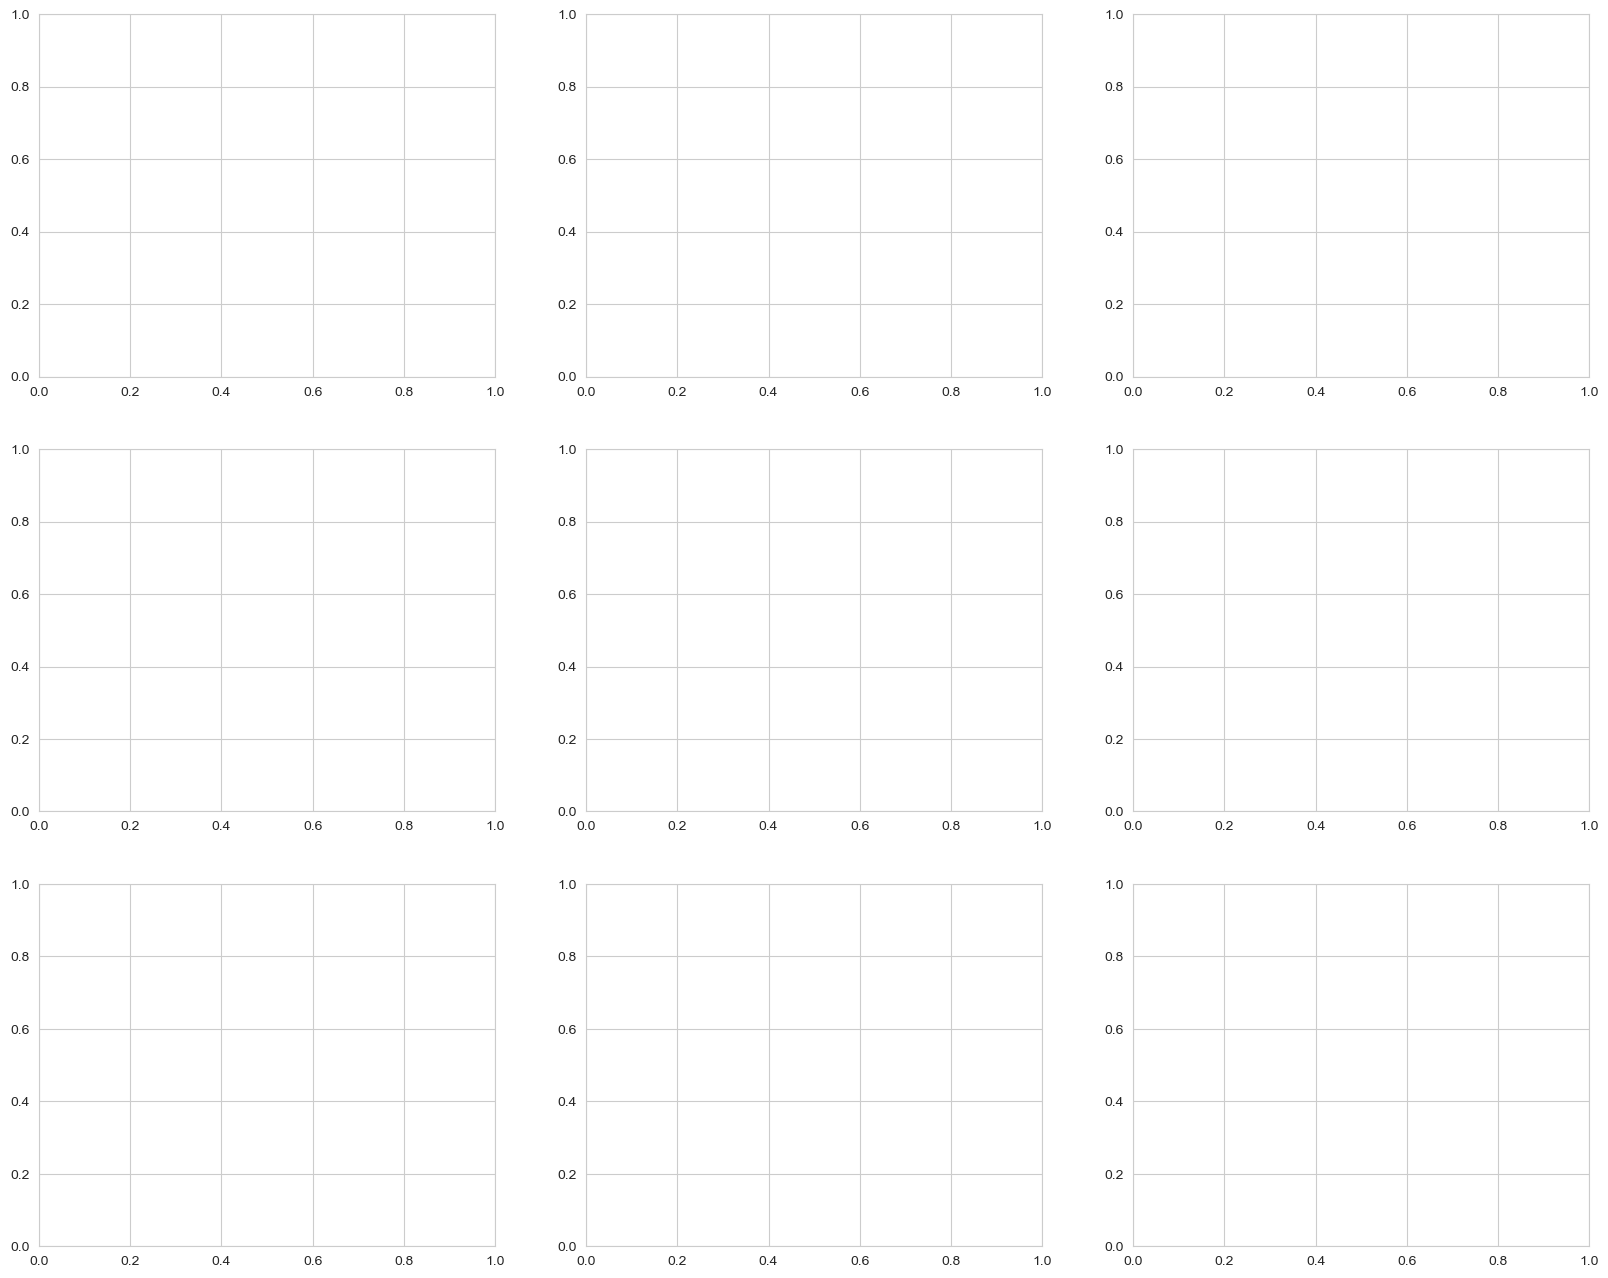

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(3, 3, figsize=(20, 16))

In [11]:
monthly = df_clean.groupby(["year", "month"])["price_per_gb"].mean().reset_index()
monthly["date"] = pd.to_datetime(monthly[["year", "month"]].assign(day=1))
axes[0, 0].plot(monthly["date"], monthly["price_per_gb"], color="#E63946", linewidth=2)
axes[0, 0].fill_between(monthly["date"], monthly["price_per_gb"], alpha=0.2, color="#E63946")
axes[0, 0].set_title("Monthly Avg Price/GB Over Time")
axes[0, 0].set_ylabel("USD / GB")
axes[0, 0].xaxis.set_major_locator(mticker.MaxNLocator(6))


In [12]:
ps_counts = df_clean["price_status"].value_counts()
colors_pie = ["#E63946", "#457B9D", "#A8DADC"]
axes[0, 1].pie(ps_counts, labels=ps_counts.index, autopct="%1.1f%%",
               colors=colors_pie, startangle=90)
axes[0, 1].set_title("Price Status Distribution")

Text(0.5, 1.0, 'Price Status Distribution')

In [13]:
sns.boxplot(data=df_clean, x="generation", y="price_per_gb",
            palette="Set2", ax=axes[0, 2], showfliers=False)
axes[0, 2].set_title("Price/GB by RAM Generation")
axes[0, 2].set_ylabel("USD / GB")

Text(1098.562091503268, 0.5, 'USD / GB')

In [14]:
sample = df_clean.sample(min(2000, len(df_clean)), random_state=42)
sc = axes[1, 0].scatter(sample["fab_utilization_rate"], sample["price_per_gb"],
                        c=sample["year"], cmap="plasma", alpha=0.4, s=15)
plt.colorbar(sc, ax=axes[1, 0], label="Year")
axes[1, 0].set_title("Fab Utilisation vs Price/GB")
axes[1, 0].set_xlabel("Fab Utilisation Rate")
axes[1, 0].set_ylabel("USD / GB")

Text(4.44444444444448, 0.5, 'USD / GB')

<Figure size 640x480 with 0 Axes>

In [15]:
axes[1, 1].scatter(sample["global_inventory_weeks"], sample["price_per_gb"],
                   c=sample["is_shortage"], cmap="RdYlGn_r", alpha=0.4, s=15)
axes[1, 1].set_title("Inventory Weeks vs Price/GB")
axes[1, 1].set_xlabel("Inventory Weeks")
axes[1, 1].set_ylabel("USD / GB")


Text(551.5032679738564, 0.5, 'USD / GB')

In [16]:
region_avg = df_clean.groupby("region")["price_per_gb"].mean().sort_values()
colors_bar = ["#457B9D" if x < region_avg.mean() else "#E63946"
              for x in region_avg]
axes[1, 2].barh(region_avg.index, region_avg.values, color=colors_bar)
axes[1, 2].set_title("Avg Price/GB by Region")
axes[1, 2].set_xlabel("USD / GB")


Text(0.5, 439.26797385620915, 'USD / GB')

In [17]:
axes[2, 0].bar(annual["year"], annual["shortage_pct"] * 100,
               color="#E63946", edgecolor="white")
axes[2, 0].set_title("Shortage-Inflated Listings by Year (%)")
axes[2, 0].set_ylabel("%")

Text(4.44444444444448, 0.5, '%')

In [18]:
seg_monthly = df_clean.groupby(["year", "market_segment"])["price_per_gb"].mean().reset_index()
for seg in seg_monthly["market_segment"].unique():
    sub = seg_monthly[seg_monthly["market_segment"] == seg]
    axes[2, 1].plot(sub["year"], sub["price_per_gb"], marker="o", label=seg)
axes[2, 1].set_title("Avg Price/GB: Enterprise vs Consumer")
axes[2, 1].set_ylabel("USD / GB")
axes[2, 1].legend()

In [19]:
hbm_monthly = df_clean.groupby(["year", "month"])["gpu_hbm_trend_gb"].mean().reset_index()
hbm_monthly["date"] = pd.to_datetime(hbm_monthly[["year", "month"]].assign(day=1))
axes[2, 2].plot(hbm_monthly["date"], hbm_monthly["gpu_hbm_trend_gb"],
                color="#2A9D8F", linewidth=2)
axes[2, 2].set_title("GPU HBM Demand Trend")
axes[2, 2].set_ylabel("HBM GB / Card (avg)")

plt.tight_layout()
plt.savefig("eda_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nEDA dashboard saved → eda_dashboard.png")


<Figure size 640x480 with 0 Axes>


EDA dashboard saved → eda_dashboard.png


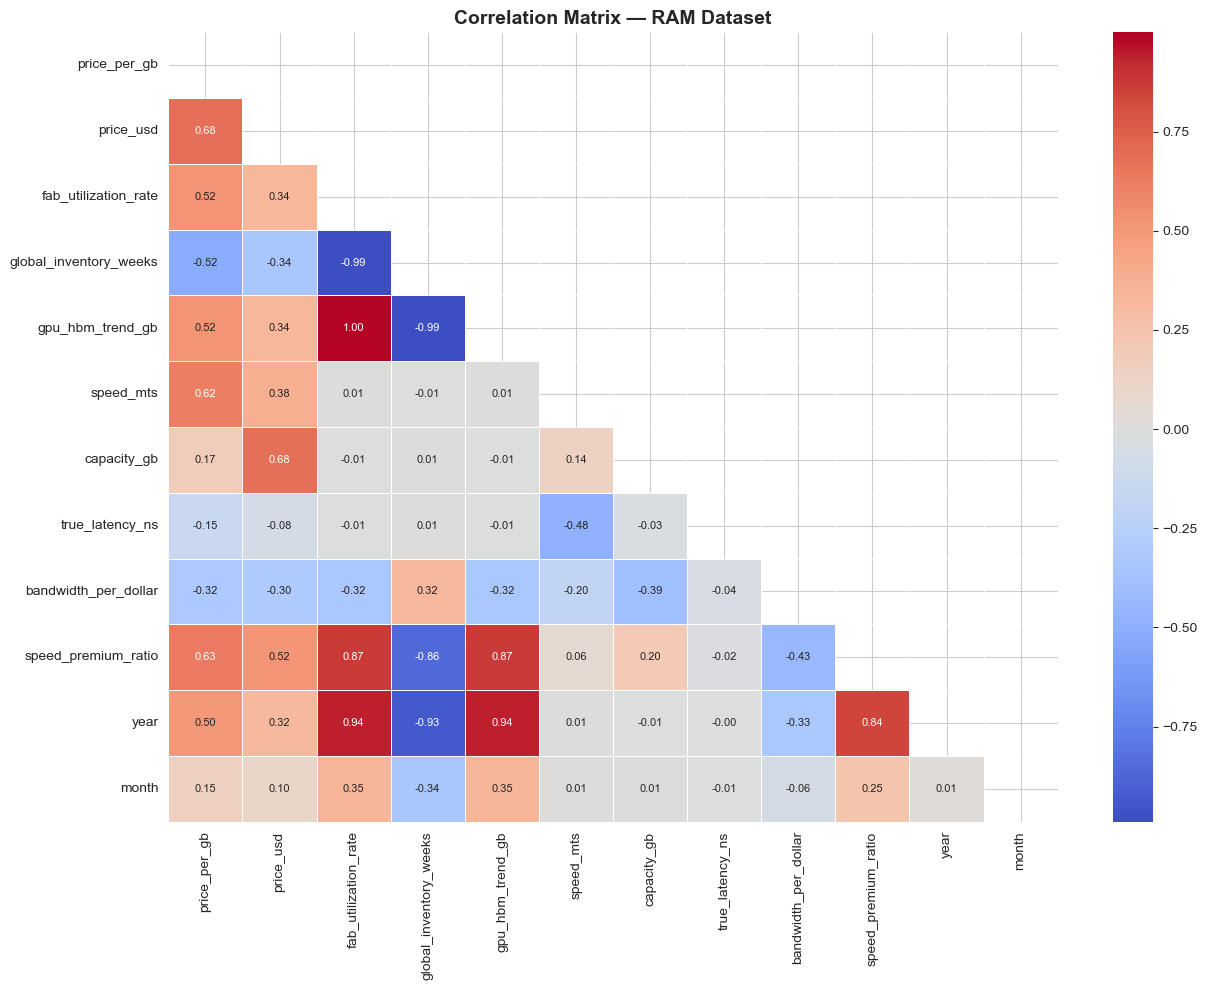

Correlation heatmap saved → correlation_heatmap.png


In [20]:
num_cols = ["price_per_gb", "price_usd", "fab_utilization_rate",
            "global_inventory_weeks", "gpu_hbm_trend_gb", "speed_mts",
            "capacity_gb", "true_latency_ns", "bandwidth_per_dollar",
            "speed_premium_ratio", "year", "month"]

corr = df_clean[num_cols].corr()
fig2, ax2 = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax2, linewidths=0.5, annot_kws={"size": 8})
ax2.set_title("Correlation Matrix — RAM Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Correlation heatmap saved → correlation_heatmap.png")

In [21]:
FEATURES = [
    "year", "month", "capacity_gb", "speed_mts",
    "fab_utilization_rate", "global_inventory_weeks",
    "gpu_hbm_trend_gb", "generation_enc", "market_segment_enc",
    "region_enc", "price_status_enc",
]
TARGET = "price_per_gb"


In [22]:
train_df = df_clean[df_clean["year"] < 2027]
test_df  = df_clean[df_clean["year"] == 2027]

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test,  y_test  = test_df[FEATURES],  test_df[TARGET]

model = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.85,
    min_samples_leaf=10,
    random_state=42,
)
model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.08
,n_estimators,300
,subsample,0.85
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


In [23]:
train_pred = model.predict(X_train)
test_pred  = model.predict(X_test)

print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)
print(f"Train  MAE  : {mean_absolute_error(y_train, train_pred):.4f}")
print(f"Train  RMSE : {np.sqrt(mean_squared_error(y_train, train_pred)):.4f}")
print(f"Train  R²   : {r2_score(y_train, train_pred):.4f}")
if len(y_test) > 0:
    print(f"Test   MAE  : {mean_absolute_error(y_test, test_pred):.4f}")
    print(f"Test   RMSE : {np.sqrt(mean_squared_error(y_test, test_pred)):.4f}")
    print(f"Test   R²   : {r2_score(y_test, test_pred):.4f}")



MODEL EVALUATION
Train  MAE  : 0.6496
Train  RMSE : 0.9477
Train  R²   : 0.9992
Test   MAE  : 3.0551
Test   RMSE : 3.5609
Test   R²   : -0.6327


In [26]:
cv_scores = cross_val_score(model, X_train, y_train, cv=5,
                             scoring="neg_mean_absolute_error")
print(f"5-Fold CV MAE: {-cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


5-Fold CV MAE: 0.8691 ± 0.0171


In [27]:
fi = (pd.Series(model.feature_importances_, index=FEATURES)
      .sort_values(ascending=False))
print("\nFeature Importances:")
print(fi.round(4).to_string())



Feature Importances:
speed_mts                 0.2523
generation_enc            0.2397
fab_utilization_rate      0.2050
gpu_hbm_trend_gb          0.1409
market_segment_enc        0.0781
global_inventory_weeks    0.0486
price_status_enc          0.0349
month                     0.0002
capacity_gb               0.0001
region_enc                0.0001
year                      0.0000


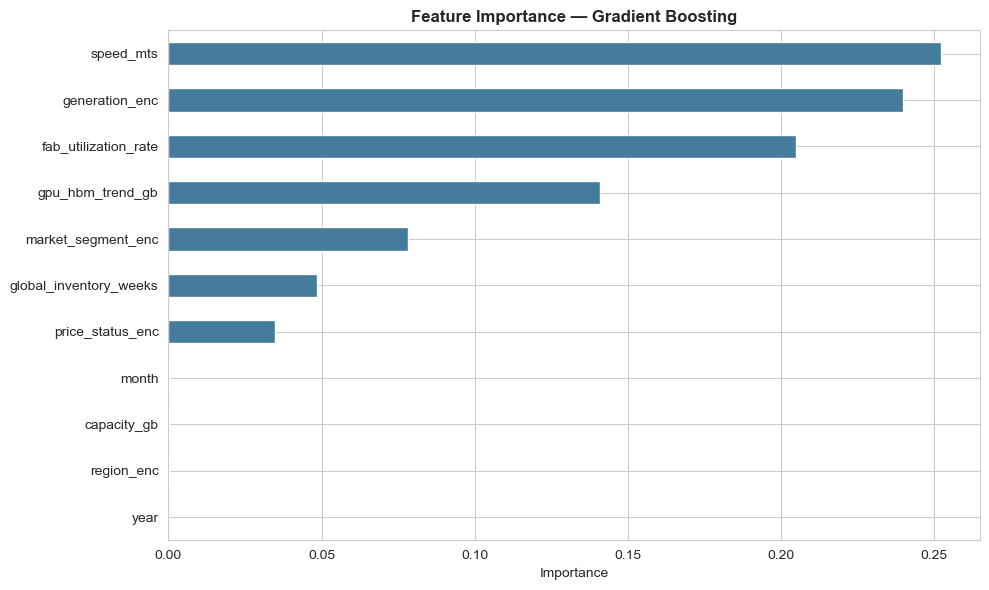

Feature importance chart saved → feature_importance.png


In [28]:
fig3, ax3 = plt.subplots(figsize=(10, 6))
fi.plot(kind="barh", color="#457B9D", ax=ax3)
ax3.set_title("Feature Importance — Gradient Boosting", fontweight="bold")
ax3.set_xlabel("Importance")
ax3.invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()
print("Feature importance chart saved → feature_importance.png")


In [29]:
baseline_2024 = df_clean[df_clean["year"] == 2024]["price_per_gb"].mean()
baseline_2025 = df_clean[df_clean["year"] == 2025]["price_per_gb"].mean()
baseline_2026 = df_clean[df_clean["year"] == 2026]["price_per_gb"].mean()

In [30]:
encoders = {}
for col in ["generation", "market_segment", "region", "price_status"]:
    le = LabelEncoder()
    df_clean[f"{col}_enc"] = le.fit_transform(df_clean[col])
    encoders[col] = le

FEATURES = [
    "year", "month", "capacity_gb", "speed_mts",
    "fab_utilization_rate", "global_inventory_weeks",
    "gpu_hbm_trend_gb", "generation_enc",
    "market_segment_enc", "region_enc", "price_status_enc",
]
TARGET = "price_per_gb"

train_df = df_clean[df_clean["year"] < 2027]
X_train  = train_df[FEATURES]
y_train  = train_df[TARGET]

model = GradientBoostingRegressor(
    n_estimators  = 300,
    max_depth     = 5,
    learning_rate = 0.08,
      subsample     = 0.85,
    random_state  = 42,
)
model.fit(X_train, y_train)
print("Model trained successfully!")


Model trained successfully!


In [31]:
baseline_2024 = df_clean[df_clean["year"] == 2024]["price_per_gb"].mean()
baseline_2025 = df_clean[df_clean["year"] == 2025]["price_per_gb"].mean()
baseline_2026 = df_clean[df_clean["year"] == 2026]["price_per_gb"].mean()

SCENARIO = {
    2027: {"fab_utilization_rate": 0.90, "global_inventory_weeks": 5.0,
           "gpu_hbm_trend_gb": 280, "capacity_gb": 64, "speed_mts": 6400,
           "price_status": "Shortage-Inflated"},
    2028: {"fab_utilization_rate": 0.85, "global_inventory_weeks": 6.5,
           "gpu_hbm_trend_gb": 330, "capacity_gb": 64, "speed_mts": 8000,
           "price_status": "Shortage-Inflated"},
}
future_records = []
for yr, params in SCENARIO.items():
    for mo in range(1, 13):
        future_records.append({
            "year"                  : yr,
            "month"                 : mo,
            "capacity_gb"           : params["capacity_gb"],
            "speed_mts"             : params["speed_mts"],
            "fab_utilization_rate"  : params["fab_utilization_rate"],
            "global_inventory_weeks": params["global_inventory_weeks"],
            "gpu_hbm_trend_gb"      : params["gpu_hbm_trend_gb"],
            "generation_enc"        : encoders["generation"].transform(["DDR5"])[0],
            "market_segment_enc"    : encoders["market_segment"].transform(["Enterprise/AI"])[0],
            "region_enc"            : encoders["region"].transform(["North America"])[0],
            "price_status_enc"      : encoders["price_status"].transform([params["price_status"]])[0],
        })

future_df = pd.DataFrame(future_records)
future_df["predicted_price_per_gb"] = model.predict(future_df[FEATURES])
future_df["date"] = pd.to_datetime(future_df[["year","month"]].assign(day=1))

avg_2027_pred = future_df[future_df["year"] == 2027]["predicted_price_per_gb"].mean()
avg_2028_pred = future_df[future_df["year"] == 2028]["predicted_price_per_gb"].mean()
pct_2027_vs_2024 = ((avg_2027_pred - baseline_2024) / baseline_2024) * 100
pct_2028_vs_2024 = ((avg_2028_pred - baseline_2024) / baseline_2024) * 100
pct_2027_vs_2026 = ((avg_2027_pred - baseline_2026) / baseline_2026) * 100
pct_2028_vs_2026 = ((avg_2028_pred - baseline_2026) / baseline_2026) * 100
pct_2028_vs_2027 = ((avg_2028_pred - avg_2027_pred) / avg_2027_pred) * 100

print("=" * 50)
print("PRICE PREDICTION RESULTS")
print("=" * 50)
print(f"Baseline  2024 avg price/GB : ${baseline_2024:.2f}")
print(f"Baseline  2025 avg price/GB : ${baseline_2025:.2f}")
print(f"Baseline  2026 avg price/GB : ${baseline_2026:.2f}")
print(f"Predicted 2027 avg price/GB : ${avg_2027_pred:.2f}")
print(f"Predicted 2028 avg price/GB : ${avg_2028_pred:.2f}")
print()
print(f"2027 vs 2024 increase : {pct_2027_vs_2024:+.1f}%")
print(f"2028 vs 2024 increase : {pct_2028_vs_2024:+.1f}%")
print(f"2027 vs 2026 increase : {pct_2027_vs_2026:+.1f}%")
print(f"2028 vs 2026 increase : {pct_2028_vs_2026:+.1f}%")
print(f"2028 vs 2027 change   : {pct_2028_vs_2027:+.1f}%")

PRICE PREDICTION RESULTS
Baseline  2024 avg price/GB : $11.65
Baseline  2025 avg price/GB : $30.16
Baseline  2026 avg price/GB : $53.94
Predicted 2027 avg price/GB : $70.79
Predicted 2028 avg price/GB : $69.09

2027 vs 2024 increase : +507.6%
2028 vs 2024 increase : +493.0%
2027 vs 2026 increase : +31.2%
2028 vs 2026 increase : +28.1%
2028 vs 2027 change   : -2.4%


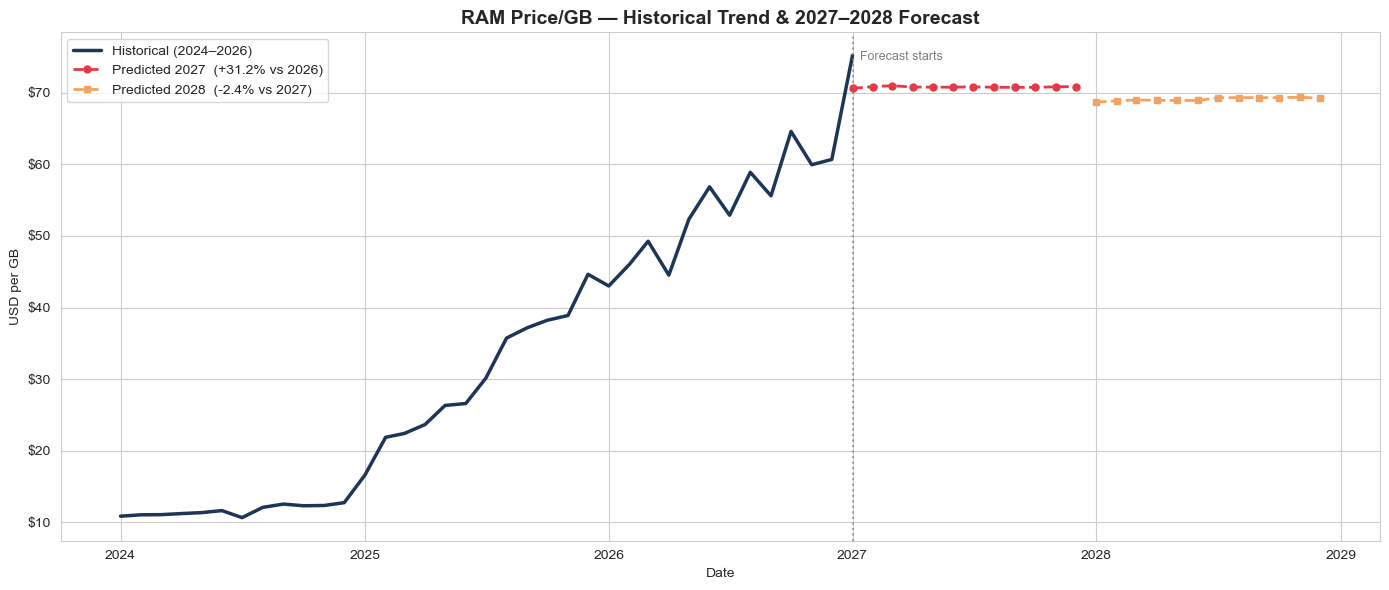

In [32]:
hist_monthly = df_clean.groupby(["year","month"])["price_per_gb"].mean().reset_index()
hist_monthly["date"] = pd.to_datetime(hist_monthly[["year","month"]].assign(day=1))

fig, ax = plt.subplots(figsize=(14, 6))

# Historical line
ax.plot(hist_monthly["date"], hist_monthly["price_per_gb"],
        color="#1D3557", linewidth=2.5,
        label="Historical (2024–2026)")

# 2027 forecast line
ax.plot(future_df[future_df["year"] == 2027]["date"],
        future_df[future_df["year"] == 2027]["predicted_price_per_gb"],
        color="#E63946", linewidth=2, linestyle="--",
        marker="o", markersize=5,
        label=f"Predicted 2027  ({pct_2027_vs_2026:+.1f}% vs 2026)")
# 2028 forecast line
ax.plot(future_df[future_df["year"] == 2028]["date"],
        future_df[future_df["year"] == 2028]["predicted_price_per_gb"],
        color="#F4A261", linewidth=2, linestyle="--",
        marker="s", markersize=5,
        label=f"Predicted 2028  ({pct_2028_vs_2027:+.1f}% vs 2027)")

# Vertical divider between history and forecast
ax.axvline(pd.Timestamp("2027-01-01"), color="gray", linestyle=":", alpha=0.7)
ax.text(pd.Timestamp("2027-01-01"), ax.get_ylim()[1] * 0.95,
        "  Forecast starts", color="gray", fontsize=9)

ax.set_title("RAM Price/GB — Historical Trend & 2027–2028 Forecast",
             fontsize=14, fontweight="bold")
ax.set_ylabel("USD per GB")
ax.set_xlabel("Date")
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))

plt.tight_layout()
plt.savefig("price_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

In [33]:
!pip install sqlalchemy psycopg2-binary --quiet


In [35]:
from sqlalchemy import create_engine , text
DB_USER     = "postgres"
DB_PASSWORD = "Debo117"
DB_HOST     = "localhost"
DB_PORT     = "5432"
DB_NAME     = "Ram_crisis"

engine = create_engine(
    f"postgresql+psycopg2://{"postgres"}:{"Debo117"}@{"localhost"}:{5432}/{"Ram_crisis"}"
)
with engine.connect() as conn:
    conn.execute(text("SELECT 1"))
print("Connected to local PostgreSQL!")

Connected to local PostgreSQL!


In [37]:
from sqlalchemy import text

schema_sql = """
CREATE TABLE IF NOT EXISTS ram_facts (
    kit_id                  TEXT PRIMARY KEY,
    brand                   TEXT,
    model_name              TEXT,
    timestamp               DATE,
    region                  TEXT,
    generation              TEXT,
    form_factor             TEXT,
    capacity_gb             INT,
    module_count            INT,
    is_ecc                  BOOLEAN,
    speed_mts               INT,
    cas_latency             INT,
    voltage                 FLOAT,
    timing_string           TEXT,
    die_manufacturer        TEXT,
    die_type                TEXT,
    true_latency_ns         FLOAT,
    bandwidth_per_dollar    FLOAT,
    latency_value_index     FLOAT,
    speed_premium_ratio     FLOAT,
    price_per_gb            FLOAT,
    price_usd               FLOAT,
    market_segment          TEXT,
    recommended_usage       TEXT,
    price_status            TEXT,
    global_inventory_weeks  FLOAT,
    fab_utilization_rate    FLOAT,
    gpu_hbm_trend_gb        FLOAT,
    year                    INT,
    month                   INT,
    quarter                 INT,
    is_shortage             INT
);

CREATE TABLE IF NOT EXISTS ram_annual_summary (
    year                INT PRIMARY KEY,
    avg_price_per_gb    FLOAT,
    avg_price_usd       FLOAT,
    avg_fab_util        FLOAT,
    avg_inventory_weeks FLOAT,
    shortage_pct        FLOAT,
    count               INT
);

CREATE TABLE IF NOT EXISTS ram_price_forecast (
    year                   INT,
    month                  INT,
    date                   DATE,
    predicted_price_per_gb FLOAT,
    model                  TEXT,
    PRIMARY KEY (year, month)
);
"""

with engine.connect() as conn:
    for stmt in schema_sql.strip().split(";"):
        stmt = stmt.strip()
        if stmt:
            conn.execute(text(stmt))
    conn.commit()

print("All 3 tables created in Ram_crisis!")

All 3 tables created in Ram_crisis!


In [38]:
cols_to_load = [
    "kit_id","brand","model_name","timestamp","region","generation",
    "form_factor","capacity_gb","module_count","is_ecc","speed_mts",
    "cas_latency","voltage","timing_string","die_manufacturer","die_type",
    "true_latency_ns","bandwidth_per_dollar","latency_value_index",
    "speed_premium_ratio","price_per_gb","price_usd","market_segment",
    "recommended_usage","price_status","global_inventory_weeks",
    "fab_utilization_rate","gpu_hbm_trend_gb","year","month","quarter","is_shortage"
]

# Load main facts table
df_clean[cols_to_load].to_sql("ram_facts", engine,
                               if_exists="replace",
                               index=False,
                               chunksize=500)
print(f" Loaded {len(df_clean):,} rows → ram_facts")

# Load annual summary
annual.to_sql("ram_annual_summary", engine,
              if_exists="replace",
              index=False)
print("Loaded → ram_annual_summary")

# Load forecast
future_df[["year","month","date","predicted_price_per_gb"]].to_sql(
    "ram_price_forecast", engine,
    if_exists="replace",
    index=False)
print("Loaded → ram_price_forecast")


 Loaded 9,792 rows → ram_facts
Loaded → ram_annual_summary
Loaded → ram_price_forecast


In [39]:
with engine.connect() as conn:

    r1 = conn.execute(text("SELECT COUNT(*) FROM ram_facts"))
    print(f"ram_facts rows        : {r1.fetchone()[0]:,}")

    r2 = conn.execute(text("SELECT COUNT(*) FROM ram_annual_summary"))
    print(f"ram_annual_summary    : {r2.fetchone()[0]}")

    r3 = conn.execute(text("SELECT COUNT(*) FROM ram_price_forecast"))
    print(f"ram_price_forecast    : {r3.fetchone()[0]}")


ram_facts rows        : 9,792
ram_annual_summary    : 4
ram_price_forecast    : 24
